## what this data is about
In an election in the USA, propositions are used in campaigns to persuade voters either to support or oppose a measure. 
Committees are formed that manage names of organisations or people who make contributions in support or opposition of a measure.
The dataset provided is for the 2016 elections for a given state in the USA. The dataset comprises:
- contributions - a dataset containing contributions made to political campaigns based on propositions of the campaigners
- committees dataset - this is a dataset of committees active in the election linked to propositions supported or opposed

In [1]:
#!conda install -c conda-forge altair --yes
#!pip install altair

In [ ]:
conda install -c conda-forge altair_saver 

In [ ]:
!pip install altair --yes

In [2]:
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt

In [3]:
# load committees dataset into a pandas data frame
committee_list = pd.read_csv("committees.csv")
#print(type(committee_list))


In [4]:
# inspect columns
committee_list.info()
# also can do  committee_list.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ocd_prop_id             102 non-null    object
 1   calaccess_prop_id       102 non-null    int64 
 2   ccdc_prop_id            102 non-null    int64 
 3   prop_name               102 non-null    object
 4   ccdc_committee_id       102 non-null    int64 
 5   calaccess_committee_id  102 non-null    int64 
 6   committee_name          102 non-null    object
 7   committee_position      102 non-null    object
dtypes: int64(4), object(4)
memory usage: 6.5+ KB


In [10]:
committee_list.head()
#committee_list.memory_usage()

,ocd_prop_id,calaccess_prop_id,ccdc_prop_id,prop_name,ccdc_committee_id,calaccess_committee_id,committee_name,committee_position
0,ocd-contest/b51dc64d-3562-4913-a190-69f5088c22a6,1376258,70,PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...,382,1374469,YES ON PROPOSITION 51 - CALIFORNIANS FOR QUALI...,SUPPORT
1,ocd-contest/b51dc64d-3562-4913-a190-69f5088c22a6,1376258,70,PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...,383,1220380,COMMUNITY COLLEGE FACILITY COALITION ISSUES CO...,SUPPORT
2,ocd-contest/b51dc64d-3562-4913-a190-69f5088c22a6,1376258,70,PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...,384,1282321,TORLAKSON'S INVEST IN CALIFORNIA A BALLOT MEAS...,SUPPORT
3,ocd-contest/b51dc64d-3562-4913-a190-69f5088c22a6,1376258,70,PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...,385,1382843,CALIFORNIA TAXPAYERS AND EDUCATORS OPPOSED TO ...,OPPOSE
4,ocd-contest/85990193-9d6f-4600-b8e7-bf1317841d82,1362198,71,PROPOSITION 052 - STATE FEES ON HOSPITALS. FED...,386,1362973,YES ON PROPOSITION 52 - A COALITION OF CALIFOR...,SUPPORT


In [6]:
committee_list['committee_name'].head(10)

0    YES ON PROPOSITION 51 - CALIFORNIANS FOR QUALI...
1    COMMUNITY COLLEGE FACILITY COALITION ISSUES CO...
2    TORLAKSON'S INVEST IN CALIFORNIA A BALLOT MEAS...
3    CALIFORNIA TAXPAYERS AND EDUCATORS OPPOSED TO ...
4    YES ON PROPOSITION 52 - A COALITION OF CALIFOR...
5    CALIFORNIANS FOR HOSPITAL ACCOUNTABILITY AND Q...
6    SERVICE EMPLOYEES INTERNATIONAL UNION, UNITED ...
7                        YES ON 53 - STOP BLANK CHECKS
8    NO ON PROP 53 - CALIFORNIANS TO PROTECT LOCAL ...
9    CA BUSINESS PAC, SP0NSORED BY CA CHAMBER OF CO...
Name: committee_name, dtype: object

In [7]:
# load contributions dataset into pandas data frame
contrib_list = pd.read_csv("contributions.csv")

In [8]:
# inspect columns/fields
contrib_list.info()
#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56379 entries, 0 to 56378
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   calaccess_committee_id        56379 non-null  int64  
 1   committee_name                56379 non-null  object 
 2   calaccess_filing_id           56379 non-null  int64  
 3   date_received                 56379 non-null  object 
 4   contributor_lastname          56375 non-null  object 
 5   contributor_firstname         53411 non-null  object 
 6   contributor_city              56369 non-null  object 
 7   contributor_state             56363 non-null  object 
 8   contributor_zip               56366 non-null  object 
 9   contributor_employer          48572 non-null  object 
 10  contributor_occupation        53273 non-null  object 
 11  contributor_is_self_employed  56379 non-null  bool   
 12  amount                        56379 non-null  float64
dtypes

In [11]:
contrib_list.contributor_lastname.head()

0            BERGMAN
1              KAHLE
2           MCDEVITT
3    WARREN-SAMARIPA
4    WARREN-SAMARIPA
Name: contributor_lastname, dtype: object

In [12]:
# list propositions field
committee_list.prop_name.head(20)

0     PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...
1     PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...
2     PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...
3     PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...
4     PROPOSITION 052 - STATE FEES ON HOSPITALS. FED...
5     PROPOSITION 052 - STATE FEES ON HOSPITALS. FED...
6     PROPOSITION 052 - STATE FEES ON HOSPITALS. FED...
7     PROPOSITION 053 - REVENUE BONDS. STATEWIDE VOT...
8     PROPOSITION 053 - REVENUE BONDS. STATEWIDE VOT...
9     PROPOSITION 053 - REVENUE BONDS. STATEWIDE VOT...
10    PROPOSITION 053 - REVENUE BONDS. STATEWIDE VOT...
11    PROPOSITION 054 - LEGISLATURE. LEGISLATION AND...
12    PROPOSITION 054 - LEGISLATURE. LEGISLATION AND...
13    PROPOSITION 054 - LEGISLATURE. LEGISLATION AND...
14    PROPOSITION 054 - LEGISLATURE. LEGISLATION AND...
15    PROPOSITION 055 - TAX EXTENSION TO FUND EDUCAT...
16    PROPOSITION 055 - TAX EXTENSION TO FUND EDUCAT...
17    PROPOSITION 055 - TAX EXTENSION TO FUND ED

In [12]:
# or first 10
committee_list.prop_name.head(10)

0    PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...
1    PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...
2    PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...
3    PROPOSITION 051 - SCHOOL BONDS. FUNDING FOR K-...
4    PROPOSITION 052 - STATE FEES ON HOSPITALS. FED...
5    PROPOSITION 052 - STATE FEES ON HOSPITALS. FED...
6    PROPOSITION 052 - STATE FEES ON HOSPITALS. FED...
7    PROPOSITION 053 - REVENUE BONDS. STATEWIDE VOT...
8    PROPOSITION 053 - REVENUE BONDS. STATEWIDE VOT...
9    PROPOSITION 053 - REVENUE BONDS. STATEWIDE VOT...
Name: prop_name, dtype: object

In [13]:
# count frequency of propositions
committee_list.prop_name.value_counts()

prop_name
PROPOSITION 057 - CRIMINAL SENTENCES. JUVENILE CRIMINAL PROCEEDINGS AND SENTENCING. INITIATIVE CONSTITUTIONAL AMENDMENT AND STATUTE.                           13
PROPOSITION 056 - CIGARETTE TAX TO FUND HEALTHCARE, TOBACCO USE PREVENTION, RESEARCH, AND LAW ENFORCEMENT. INITIATIVE CONSTITUTIONAL AMENDMENT AND STATUTE.    12
PROPOSITION 064- MARIJUANA LEGALIZATION. INITIATIVE STATUTE.                                                                                                   11
PROPOSITION 066- DEATH PENALTY. PROCEDURES. INITIATIVE STATUTE.                                                                                                 9
PROPOSITION 055 - TAX EXTENSION TO FUND EDUCATION AND HEALTHCARE. INITIATIVE CONSTITUTIONAL AMENDMENT.                                                          8
PROPOSITION 067- REFERENDUM TO OVERTURN BAN ON SINGLE-USE PLASTIC BAGS.                                                                                         7
PROPOSITION 062- D

In [14]:
# tidy up the count
committee_list.prop_name.value_counts().reset_index()

,prop_name,count
0,PROPOSITION 057 - CRIMINAL SENTENCES. JUVENILE...,13
1,PROPOSITION 056 - CIGARETTE TAX TO FUND HEALTH...,12
2,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,11
3,PROPOSITION 066- DEATH PENALTY. PROCEDURES. IN...,9
4,PROPOSITION 055 - TAX EXTENSION TO FUND EDUCAT...,8
5,PROPOSITION 067- REFERENDUM TO OVERTURN BAN ON...,7
6,PROPOSITION 062- DEATH PENALTY. INITIATIVE STA...,7
7,"PROPOSITION 059- SB 254 (CHAPTER 20, STATUTES ...",6
8,"PROPOSITION 058 - SB 1174 (CHAPTER 753, STATUT...",4
9,PROPOSITION 063- FIREARMS. AMMUNITION SALES. I...,4


In [16]:
# we filter our data on a specific proposition
my_prop = 'PROPOSITION 064- MARIJUANA LEGALIZATION. INITIATIVE STATUTE.'

In [11]:
committee_list.prop_name == my_prop

0      False
1      False
2      False
3      False
4      False
       ...  
97     False
98     False
99     False
100    False
101    False
Name: prop_name, Length: 102, dtype: bool

In [17]:
my_committees = committee_list[committee_list.prop_name == my_prop]

In [14]:
my_committees = committee_list[committee_list.prop_name == my_prop]

In [18]:
my_committees.head()

,ocd_prop_id,calaccess_prop_id,ccdc_prop_id,prop_name,ccdc_committee_id,calaccess_committee_id,committee_name,committee_position
74,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,456,1381808,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",SUPPORT
75,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,457,1382525,NEW APPROACH PAC (MPO),SUPPORT
76,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,458,1376077,"CALIFORNIANS FOR SENSIBLE REFORM, SPONSORED BY...",SUPPORT
77,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,459,1382568,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",OPPOSE
78,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,460,1371855,"MARIJUANA POLICY PROJECT OF CALIFORNIA, YES ON 64",SUPPORT


In [16]:
#contrib_list["calaccess_committee_id"]
my_committees["calaccess_committee_id"]

74    1381808
75    1382525
76    1376077
77    1382568
78    1371855
79    1343793
80    1386560
81    1387789
82    1385506
83    1385745
84    1390962
Name: calaccess_committee_id, dtype: int64

In [12]:
my_committees.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 74 to 84
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ocd_prop_id             11 non-null     object
 1   calaccess_prop_id       11 non-null     int64 
 2   ccdc_prop_id            11 non-null     int64 
 3   prop_name               11 non-null     object
 4   ccdc_committee_id       11 non-null     int64 
 5   calaccess_committee_id  11 non-null     int64 
 6   committee_name          11 non-null     object
 7   committee_position      11 non-null     object
dtypes: int64(4), object(4)
memory usage: 792.0+ bytes


In [19]:
# produce a dataset merged on calcaccess committee id
merged = pd.merge(my_committees, contrib_list, on="calaccess_committee_id")
merged.head()

,ocd_prop_id,calaccess_prop_id,ccdc_prop_id,prop_name,ccdc_committee_id,calaccess_committee_id,committee_name_x,committee_position,committee_name_y,calaccess_filing_id,date_received,contributor_lastname,contributor_firstname,contributor_city,contributor_state,contributor_zip,contributor_employer,contributor_occupation,contributor_is_self_employed,amount
0,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,456,1381808,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",SUPPORT,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",2038581,2016-02-04,BRADEN QUIGLEY,LAURA,SACRAMENTO,CA,95825,LBQ STRATEGIES,CONSULTANT,False,100.0
1,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,456,1381808,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",SUPPORT,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",2038581,2016-01-05,"CALIFORNIANS FOR SENSIBLE REFORM, SPONSORED BY...",NaN,IRVINE,CA,92618,NaN,NaN,False,250000.0
2,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,456,1381808,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",SUPPORT,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",2038581,2016-01-29,"CALIFORNIANS FOR SENSIBLE REFORM, SPONSORED BY...",NaN,IRVINE,CA,92618,NaN,NaN,False,250000.0
3,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,456,1381808,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",SUPPORT,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",2038581,2016-03-28,"CALIFORNIANS FOR SENSIBLE REFORM, SPONSORED BY...",NaN,IRVINE,CA,92618,NaN,NaN,False,250000.0
4,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,456,1381808,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",SUPPORT,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",2038581,2016-01-05,DRUG POLICY ACTION,NaN,NEW YORK,NY,10001,NaN,NaN,False,250000.0


In [20]:
# what is the total amount raised for this proposition?
#merged.amount
merged.amount.sum()

35177017.64

In [19]:
merged.committee_position.head()

0    SUPPORT
1    SUPPORT
2    SUPPORT
3    SUPPORT
4    SUPPORT
Name: committee_position, dtype: object

In [21]:
# get committees in support or oppossing from the merged dataset
support = merged[merged.committee_position == 'SUPPORT']
oppose = merged[merged.committee_position == 'OPPOSE']

In [22]:
# how much was raised in opposition?
oppose.amount.sum()

2501211.64

In [23]:
# how much was raised in support?
support.amount.sum()

32675806.0

In [24]:
# % of support to total contributions
support.amount.sum() / merged.amount.sum()

0.9288964270479867

In [25]:
# check first largest amounts contributed
merged.sort_values("amount", ascending=False).head()

,ocd_prop_id,calaccess_prop_id,ccdc_prop_id,prop_name,ccdc_committee_id,calaccess_committee_id,committee_name_x,committee_position,committee_name_y,calaccess_filing_id,date_received,contributor_lastname,contributor_firstname,contributor_city,contributor_state,contributor_zip,contributor_employer,contributor_occupation,contributor_is_self_employed,amount
142,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,456,1381808,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",SUPPORT,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",2083528,2016-09-15,PARKER AND AFFILIATED ENTITIES,SEAN,PALO ALTO,CA,94301,NaN,NaN,False,4000000.0
79,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,456,1381808,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",SUPPORT,"YES ON 64, CALIFORNIANS TO CONTROL, REGULATE A...",2083528,2016-09-15,"DRUG POLICY ACTION - NON PROFIT 501C4, YES ON ...",NaN,SACRAMENTO,CA,95815,NaN,NaN,False,2000000.0
846,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,464,1385506,"DRUG POLICY ACTION - NON PROFIT 501C4, YES ON ...",SUPPORT,"DRUG POLICY ACTION - NON PROFIT 501C4, YES ON ...",2083608,2016-09-15,FUND FOR POLICY REFORM (NONPROFIT 501 (C)(4)),NaN,NEW YORK,NY,10019,NaN,NaN,False,1970000.0
851,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,465,1385745,FUND FOR POLICY REFORM (NONPROFIT 501(C)(4)),SUPPORT,FUND FOR POLICY REFORM (NONPROFIT 501(C)(4)),2082414,2016-09-15,FUND FOR POLICY REFORM,NaN,WILMINGTON,DE,19809,NaN,NaN,False,1970000.0
852,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,465,1385745,FUND FOR POLICY REFORM (NONPROFIT 501(C)(4)),SUPPORT,FUND FOR POLICY REFORM (NONPROFIT 501(C)(4)),2096507,2016-09-27,FUND FOR POLICY REFORM,NaN,WILMINGTON,DE,19809,NaN,NaN,False,1403000.0


In [25]:
# highest amounts donated in support
#support.sort_values("amount", ascending=False).head()

committee_list.columns.values

array(['ocd_prop_id', 'calaccess_prop_id', 'ccdc_prop_id', 'prop_name',
       'ccdc_committee_id', 'calaccess_committee_id', 'committee_name',
       'committee_position'], dtype=object)

In [26]:
contrib_list.columns

Index(['calaccess_committee_id', 'committee_name', 'calaccess_filing_id',
       'date_received', 'contributor_lastname', 'contributor_firstname',
       'contributor_city', 'contributor_state', 'contributor_zip',
       'contributor_employer', 'contributor_occupation',
       'contributor_is_self_employed', 'amount'],
      dtype='object')

In [26]:
# 5 highest amounts in opposition
oppose.sort_values("amount", ascending=False).head()

,ocd_prop_id,calaccess_prop_id,ccdc_prop_id,prop_name,ccdc_committee_id,calaccess_committee_id,committee_name_x,committee_position,committee_name_y,calaccess_filing_id,date_received,contributor_lastname,contributor_firstname,contributor_city,contributor_state,contributor_zip,contributor_employer,contributor_occupation,contributor_is_self_employed,amount
839,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,463,1387789,"SAM ACTION, INC., A COMMITTEE AGAINST PROPOSIT...",OPPOSE,"SAM ACTION, INC., A COMMITTEE AGAINST PROPOSIT...",2083142,2016-07-20,SCHAUER,JULIE,OAKS,PA,19456,NaN,RETIRED,False,1000000.0
312,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,459,1382568,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",OPPOSE,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",2098048,2016-09-27,"SAM ACTION, INC.",NaN,ALEXANDRIA,VA,22314,NaN,NaN,False,400000.0
310,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,459,1382568,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",OPPOSE,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",2083071,2016-09-15,"SAM ACTION, INC.",NaN,ALEXANDRIA,VA,22314,NaN,NaN,False,225000.0
308,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,459,1382568,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",OPPOSE,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",2083071,2016-09-12,"SAM ACTION, INC.",NaN,ALEXANDRIA,VA,22314,NaN,NaN,False,200000.0
840,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,463,1387789,"SAM ACTION, INC., A COMMITTEE AGAINST PROPOSIT...",OPPOSE,"SAM ACTION, INC., A COMMITTEE AGAINST PROPOSIT...",2083142,2016-07-25,SCHAUER,JULIE,OAKS,CA,19456,NaN,RETIRED,False,150000.0


In [28]:
#merged["contributor_state"]
# group contributions by state of the contributor and total them for each state
merged.groupby("contributor_state").amount.sum()

contributor_state
AB           0.00
AL         100.00
AZ         500.00
BC           0.00
CA    17491193.00
CO       39300.00
CT         100.00
DC     2618600.00
DE     6140100.00
FL     1250850.00
GA         100.00
ID        1000.00
IL        7000.00
LA         100.00
MA         600.00
MD        2971.00
MI         400.00
MO         550.00
NC         200.00
NV        1800.00
NY     5446985.00
OH        2950.00
OK         200.00
OR        1400.00
PA     1215475.00
RI        6700.00
TX        1800.00
VA      895243.64
WA       50800.00
Name: amount, dtype: float64

In [29]:
# a neater table
merged.groupby("contributor_state").amount.sum().reset_index()

,contributor_state,amount
0,AB,0.00
1,AL,100.00
2,AZ,500.00
3,BC,0.00
4,CA,17491193.00
5,CO,39300.00
6,CT,100.00
7,DC,2618600.00
8,DE,6140100.00
9,FL,1250850.00


In [30]:
# we can sort them by total amounts
#merged.groupby("contributor_state").amount.sort_values("amount", ascending=False).sum()
merged.groupby("contributor_state").amount.sum().reset_index().sort_values("amount", ascending=False)

,contributor_state,amount
4,CA,17491193.00
8,DE,6140100.00
20,NY,5446985.00
7,DC,2618600.00
9,FL,1250850.00
24,PA,1215475.00
27,VA,895243.64
28,WA,50800.00
5,CO,39300.00
12,IL,7000.00


In [31]:
# include multiple columns in group by
merged.groupby(["contributor_firstname", "contributor_lastname"]).amount.sum().reset_index().\
sort_values("amount", ascending=False).head(10)

,contributor_firstname,contributor_lastname,amount
483,SEAN,PARKER AND AFFILIATED ENTITIES,7250000.0
482,SEAN,PARKER,1500000.0
281,JULIE,SCHAUER,1364000.0
108,DANIEL,LEWIS,1250000.0
194,HENRY,VAN AMERINGEN,1000000.0
405,NICHOLAS,PRITZKER,900000.0
421,PETER,THIEL,300000.0
456,ROGER,JENKINS,75000.0
23,ANGELA,HOWARD,65000.0
322,LAWRENCE,HESS,30000.0


In [32]:
# find out whether a contributor supported or opposed
merged.groupby(["contributor_firstname", "contributor_lastname", "committee_position"]).amount.sum().reset_index().sort_values("amount", ascending=False)

,contributor_firstname,contributor_lastname,committee_position,amount
483,SEAN,PARKER AND AFFILIATED ENTITIES,SUPPORT,7250000.0
482,SEAN,PARKER,SUPPORT,1500000.0
281,JULIE,SCHAUER,OPPOSE,1364000.0
108,DANIEL,LEWIS,SUPPORT,1250000.0
194,HENRY,VAN AMERINGEN,SUPPORT,1000000.0
...,...,...,...,...
430,RICH,GOLDBERG,SUPPORT,25.0
358,MARSTON,MEDLOCK,SUPPORT,0.0
497,STEPHANIE,WARREN-SAMARIPA,SUPPORT,0.0
16,AMIRGHASEM,SAMIMI-ARDESTAN,SUPPORT,0.0


In [33]:
# see supporters only
support.groupby(["contributor_firstname", "contributor_lastname"]).amount.sum().reset_index().sort_values("amount", ascending=False)

,contributor_firstname,contributor_lastname,amount
444,SEAN,PARKER AND AFFILIATED ENTITIES,7250000.0
443,SEAN,PARKER,1500000.0
102,DANIEL,LEWIS,1250000.0
180,HENRY,VAN AMERINGEN,1000000.0
374,NICHOLAS,PRITZKER,900000.0
...,...,...,...
328,MARK,SLABAUGH,25.0
128,DAVID,WOOD,0.0
16,AMIRGHASEM,SAMIMI-ARDESTAN,0.0
458,STEPHANIE,WARREN-SAMARIPA,0.0


In [34]:
# see those opposing only
oppose.groupby(["contributor_firstname", "contributor_lastname"]).amount.sum().reset_index().sort_values("amount", ascending=False)

,contributor_firstname,contributor_lastname,amount
20,JULIE,SCHAUER,1364000.0
31,ROBERT,ADAMS,6500.0
29,MICHAEL,DEAN,5000.0
13,GEORGE,BELL,1550.0
12,FARSHAD,FARDAD,1000.0
17,JESSICA,MACIEL,1000.0
9,EDITH,REUVENI,1000.0
3,CHRISTINE,MILLER,871.0
25,LORI,ROBINSON,817.0
8,DWIGHT,BELL,730.0


In [35]:
# take care of missing firstnames 
merged.fillna("").groupby(["contributor_firstname", "contributor_lastname", "committee_position"]).\
amount.sum().reset_index().sort_values("amount", ascending=False)

,contributor_firstname,contributor_lastname,committee_position,amount
554,SEAN,PARKER AND AFFILIATED ENTITIES,SUPPORT,7250000.0
31,,FUND FOR POLICY REFORM,SUPPORT,6140000.0
32,,FUND FOR POLICY REFORM (NONPROFIT 501 (C)(4)),SUPPORT,3940000.0
24,,"DRUG POLICY ACTION - NON PROFIT 501C4, YES ON ...",SUPPORT,3000000.0
49,,NEW APPROACH PAC (MPO),SUPPORT,2615000.0
...,...,...,...,...
501,RICH,GOLDBERG,SUPPORT,25.0
429,MARSTON,MEDLOCK,SUPPORT,0.0
568,STEPHANIE,WARREN-SAMARIPA,SUPPORT,0.0
207,DAVID,WOOD,SUPPORT,0.0


In [36]:
# top supporters
top_supporters = support.fillna("").groupby(
    ["contributor_firstname", "contributor_lastname"]
).amount.sum().reset_index().sort_values("amount", ascending=False).head(10)

In [37]:
# view them
top_supporters.head()

,contributor_firstname,contributor_lastname,amount
487,SEAN,PARKER AND AFFILIATED ENTITIES,7250000.0
19,,FUND FOR POLICY REFORM,6140000.0
20,,FUND FOR POLICY REFORM (NONPROFIT 501 (C)(4)),3940000.0
12,,"DRUG POLICY ACTION - NON PROFIT 501C4, YES ON ...",3000000.0
31,,NEW APPROACH PAC (MPO),2615000.0


In [38]:
# produce a plot

alt.Chart(top_supporters).mark_bar().encode(
    x="contributor_lastname",
    y="amount")

alt.Chart(...)

In [ ]:
#top_supporters.to_csv('topSupporters.csv')
top_supporters

## a seaborn bar plot

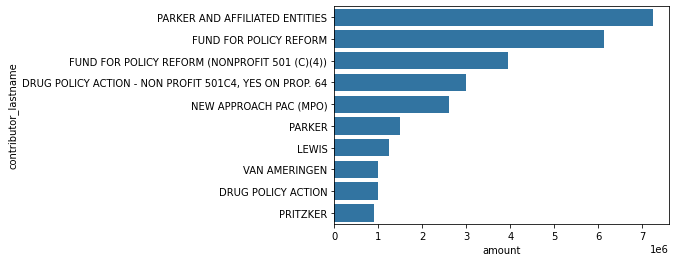

In [39]:
import seaborn as sns
#plt.figure();
x = top_supporters.amount
y = top_supporters.contributor_lastname

ax = sns.barplot(x=x, y=y, data=top_supporters)
plt.show()

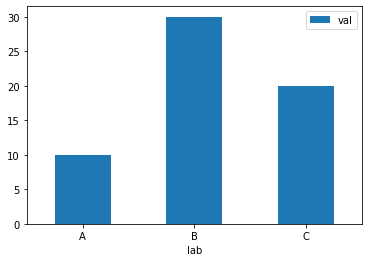

In [41]:
df = pd.DataFrame({'lab':['A', 'B', 'C'], 'val':[10, 30, 20]})
ax = df.plot.bar(x='lab', y='val', rot=0)

In [33]:
# horizontal view
alt.Chart(top_supporters).mark_bar().encode(
    x="amount",
    y="contributor_lastname")

alt.Chart(...)

In [40]:
# combine first name and last name to produce full name
top_supporters['contributor_fullname'] = top_supporters.contributor_firstname + " " + top_supporters.contributor_lastname

In [41]:
top_supporters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 487 to 417
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contributor_firstname  10 non-null     object 
 1   contributor_lastname   10 non-null     object 
 2   amount                 10 non-null     float64
 3   contributor_fullname   10 non-null     object 
dtypes: float64(1), object(3)
memory usage: 400.0+ bytes


In [73]:
f = "Python"
t = "programming"
f + t

'Pythonprogramming'

In [42]:
# plot on full name
alt.Chart(top_supporters.head(10)).mark_bar().encode(
    x="amount",
    y="contributor_fullname")

alt.Chart(...)

In [43]:
# lets sort the graph on x axis
alt.Chart(top_supporters.head(10)).mark_bar().encode(
    x="amount",
    y=alt.Y("contributor_fullname", sort="-x"))

alt.Chart(...)

In [44]:
# we can also add a title to the plot
alt.Chart(top_supporters.head(10)).mark_bar().encode(
    x="amount",
    y=alt.Y("contributor_fullname", sort="-x")
).properties(
    title="Top Spenders in Support of Proposition 64")



alt.Chart(...)

In [45]:
# who spent the most in support or opposing?
top_contributors = merged.fillna("").groupby(
    ["contributor_firstname", "contributor_lastname","committee_position"]
).amount.sum().reset_index().sort_values("amount", ascending=False).head(10)

In [46]:
top_contributors["contributor_fullname"] = top_contributors["contributor_firstname"] + " " + top_contributors["contributor_lastname"]

In [47]:
# plot and sort
alt.Chart(top_contributors.head(10)).mark_bar().encode(
    x="amount",
    y=alt.Y("contributor_fullname",sort="-x"),)

alt.Chart(...)

In [48]:
# distinguish support and oppose using color
alt.Chart(top_contributors.head(20)).mark_bar().encode(
    x="amount",
    y=alt.Y("contributor_fullname",sort="-x"),
    color="committee_position")

alt.Chart(...)

In [49]:
# write your top ten supporters to a csv file
top_supporters.to_csv("top_supporters.csv")

### programmatically saving altair charts
- requires additional installs
To programmatically export `png` or `svg`,  requires the Selenium package and either Google Chrome or Mozilla Firefox browser, plus a corresponding driver to be installed.

https://altair-viz.github.io/user_guide/saving_charts.html#png-and-svg-format 

In [ ]:
mychart = alt.Chart(top_contributors.head(20)).mark_bar().encode(
    x="amount",
    y=alt.Y("contributor_fullname",sort="-x"),
    color="committee_position")

In [ ]:
mychart.save('chart.png')
mychart.save('chart.svg')
mychart.save('chart.pdf')

In [59]:
oppose = oppose.fillna("")
oppose[oppose["contributor_firstname"].str.contains('JE')]

,ocd_prop_id,calaccess_prop_id,ccdc_prop_id,prop_name,ccdc_committee_id,calaccess_committee_id,committee_name_x,committee_position,committee_name_y,calaccess_filing_id,date_received,contributor_lastname,contributor_firstname,contributor_city,contributor_state,contributor_zip,contributor_employer,contributor_occupation,contributor_is_self_employed,amount
324,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,459,1382568,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",OPPOSE,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",2098048,2016-10-12,MACIEL,JESSICA,CORPUS CHRISTI,TX,78418,NON,SELF,False,1000.0
338,ocd-contest/232cb72c-1b11-4293-b4e2-a181e80d172e,1381868,83,PROPOSITION 064- MARIJUANA LEGALIZATION. INITI...,459,1382568,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",OPPOSE,"PUBLIC AND MENTAL HEALTH ADVOCATES AGAINST 64,...",2098048,2016-10-18,FORBES,JEREMY,LA JOLLA,CA,92037,,NOT EMPLOYED,False,100.0


In [60]:

top_contributors[top_contributors['contributor_fullname'].str.contains("SEA")]

,contributor_firstname,contributor_lastname,committee_position,amount,contributor_fullname
554,SEAN,PARKER AND AFFILIATED ENTITIES,SUPPORT,7250000.0,SEAN PARKER AND AFFILIATED ENTITIES
553,SEAN,PARKER,SUPPORT,1500000.0,SEAN PARKER
